In [1]:
import pandas as pd
import pingouin as pg

In [ ]:
# Simple_df contains clinical, epts and mri features, and the worsening label. Not published due to confidentiality of the patient data,
# but the code to read it is included here for reproducibility of the analysis.
df = pd.read_csv('simple_df.csv')
# Make all columns numeric
df = df.apply(pd.to_numeric)
df['Worsening'] = df['Worsening'].astype(float)

In [3]:
# Variables to test
variables = df.columns[:-1]

# Initialize results list
results = []

# Loop through each variable
for var in variables:
    # Perform Mann-Whitney U test
    mwu = pg.mwu(df[df['Worsening'] == 1.0][var],
                 df[df['Worsening'] == 0.0][var])
    mwu['variable'] = var  # Add variable name
    results.append(mwu)

# Combine all results into a single DataFrame
results_df = pd.concat(results).reset_index(drop=True)

# Adjust p-values for multiple comparisons using Benjamini-Hochberg (FDR)
results_df['p-adjusted'] = pg.multicomp(results_df['p-val'].values, method='fdr_bh')[1]
results_df['p-adjusted-bonf'] = pg.multicomp(results_df['p-val'].values, method='bonf')[1]

In [4]:
# We are translating the following:
# [
#     "mri_lstlpa.Lesion.Volume_vol",
#     "mri_Left.Inf.Lat.Vent_vol",
#     "mri_original_shape_LeastAxisLength",
#     "mri_original_shape_Maximum2DDiameterSlice",
#     "mri_original_shape_Maximum3DDiameter",
#     "mri_original_shape_MeshVolume",
#     "mri_original_shape_MinorAxisLength",
#     "mri_original_shape_SurfaceArea",
#     "mri_original_shape_VoxelVolume",
#     "mri_original_firstorder_Energy",
#     "mri_original_firstorder_TotalEnergy",
#     "mri_original_glcm_Imc1",
#     "mri_original_glcm_Imc2",
#     "mri_original_glrlm_RunLengthNonUniformity",
#     "mri_original_glszm_GrayLevelNonUniformity",
#     "mri_original_glszm_SizeZoneNonUniformity",
#     "mri_original_gldm_DependenceNonUniformity",
#     "mri_original_shape_MajorAxisLength_NAWM",
#     "mri_original_glrlm_RunLengthNonUniformity_NAWM",
#     "mri_original_glszm_GrayLevelNonUniformity_NAWM",
#     "epts_latency_apb_r",
#     "epts_SY_SlidingWindow_m_s2_2_ah_r",
#     "epts_latency_ah_r"
# ]
human_readable = [
    "MRI Lesion Volume",
    "MRI Left Inferior Lateral Ventricle Volume",
    "Lesion Least Axis Length (Shape)",
    "Lesion Max 2D Diameter (Slice)",
    "Lesion Max 3D Diameter",
    "Lesion Mesh Volume",
    "Lesion Minor Axis Length",
    "Lesion Surface Area",
    "Lesion Voxel Volume",
    "Lesion Energy (First Order)",
    "Lesion Total Energy",
    "Lesion Imc1 (GLCM)",
    "Lesion Imc2 (GLCM)",
    "Lesion Run Length Non-Uniformity (GLRLM)",
    "Lesion Gray Level Non-Uniformity (GLSZM)",
    "Lesion Size Zone Non-Uniformity (GLSZM)",
    "Lesion Dependence Non-Uniformity (GLDM)",
    "NAWM Major Axis Length",
    "NAWM Run Length Non-Uniformity",
    "NAWM Gray Level Non-Uniformity",
    "EPTS Latency (APB) (Right)",
    "EPTS Sliding Window (SY_m_s2_2) (AH) (Right)",
    "EPTS Latency (AH) (Right)"
]
human_readable = [
    "MRI Lesion Volume",
    "MRI Left Inferior Lateral Ventricle Volume",
    "MRI Least Axis Length (WML, Shape)",
    "MRI Max 2D Diameter (WML, Shape)",
    "MRI Max 3D Diameter (WML, Shape)",
    "MRI Mesh Volume (WML, Shape)",
    "MRI Minor Axis Length (WML, Shape)",
    "MRI Surface Area (WML, Shape)",
    "MRI Lesion Voxel Volume",
    "MRI Energy (WML, First Order)",
    "MRI Total Energy (WML, First Order)",
    "MRI GLCM Imc1 (WML, Textural)",
    "MRI GLCM Imc2 (WML, Textural)",
    "MRI GLRLM Run Length Non-Uniformity (WML, Textural)",
    "MRI GLSZM Grey Level Non-Uniformity (WML, Textural)",
    "MRI GLSZM Size Non-Uniformity (WML, Textural)",
    "MRI GLDM Dependence Non-Uniformity (WML, Textural)",
    "MRI Major Axis Length (NAWM, Shape)",
    "MRI GLRLM Run Length Non-Uniformity (NAWM, Textural)",  # This should be confirmed by Lorin
    "MRI GLSZM Gray Level Non-Uniformity (NAWM, Textural)",  # This should be confirmed by Lorin
    "EPTS Latency (APB, Right)",
    "EPTS Sliding Window Feature (AH, Right)",
    "EPTS Latency (AH, Right)"
]
results_df.loc[results_df['p-adjusted'] < 0.05,'human_readable'] = human_readable

/tmp/ipykernel_3677483/1129196995.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Stable', 'Worsening'])
/tmp/ipykernel_3677483/1129196995.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Stable', 'Worsening'])
/tmp/ipykernel_3677483/1129196995.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Stable', 'Worsening'])
/tmp/ipykernel_3677483/1129196995.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Stable', 'Worsening'])
/tmp/ipykernel_3677483/1129196995.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_tick

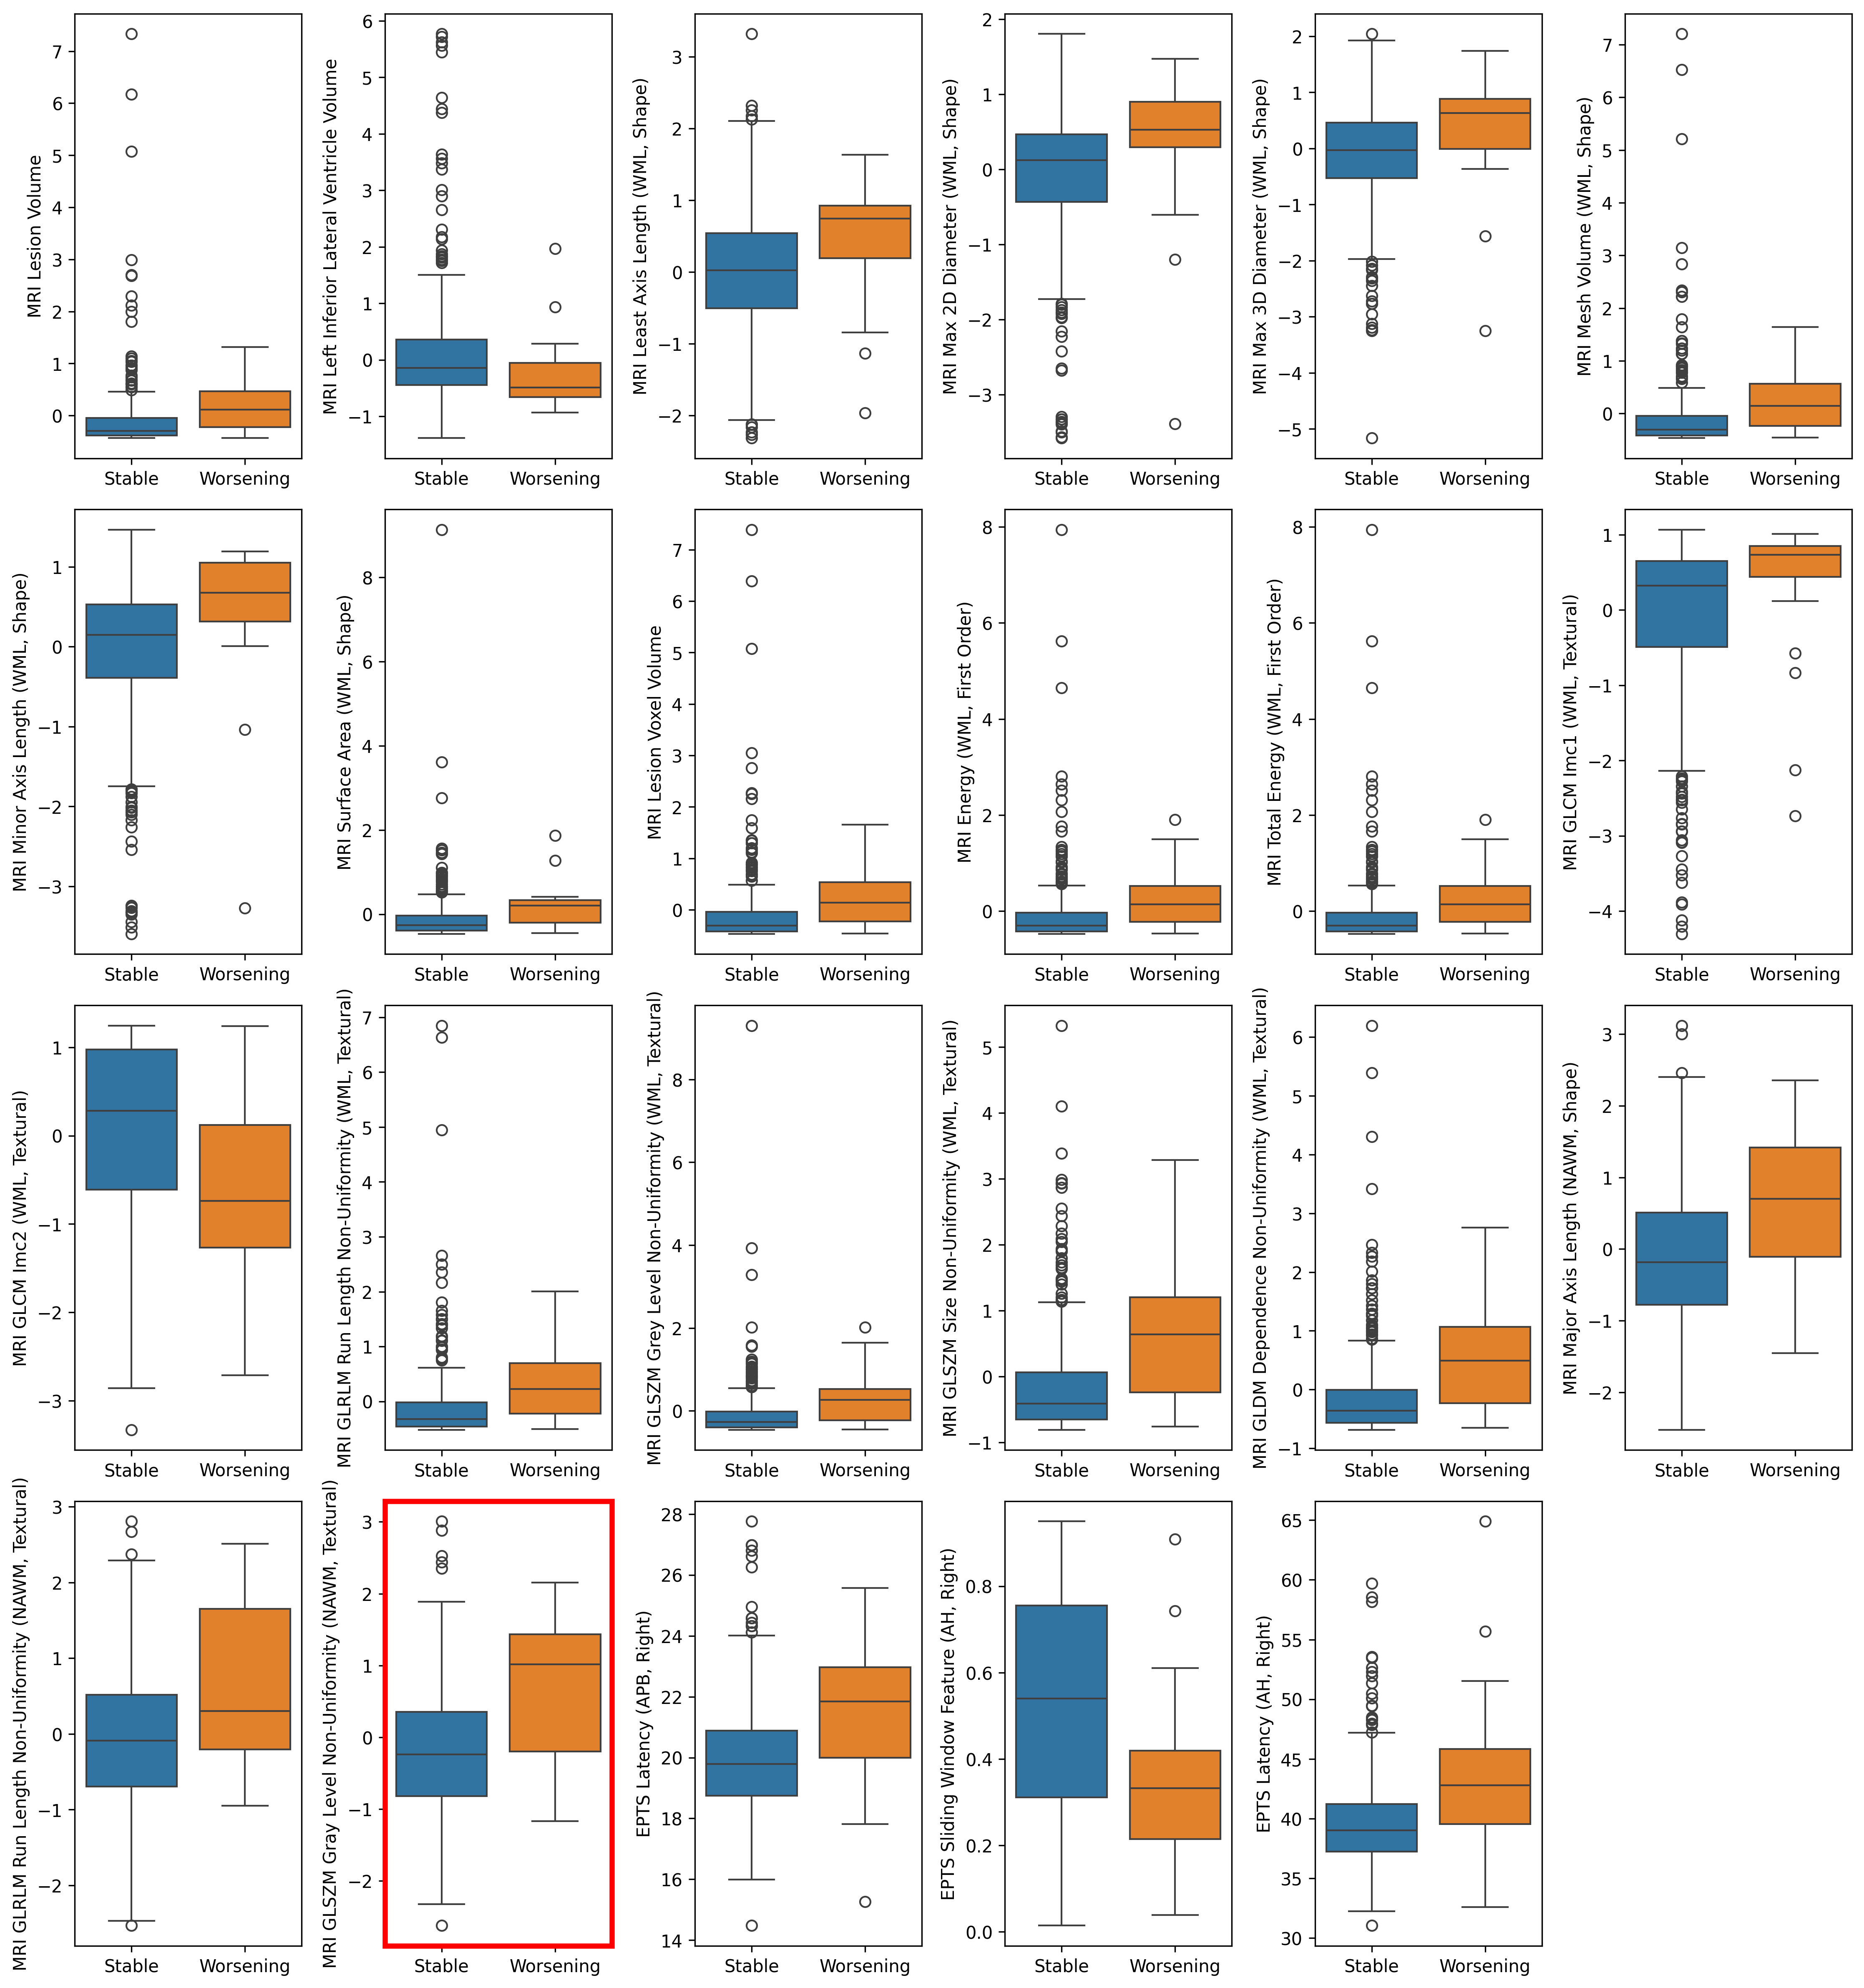

In [ ]:
from matplotlib import pyplot as plt
from matplotlib import patches
import seaborn as sns

p_col = 'p-adjusted'

col = results_df[results_df[p_col] < 0.05].iloc[0]['variable']

# Determine optimal rows and columns
n = (results_df[p_col] < 0.05).sum()
ncols = 6
nrows = -(-n // ncols)  # Ceiling division

fig, axs = plt.subplots(nrows, ncols, figsize=(15, 16), dpi=300)

if nrows == 1 and ncols == 1:
    axs = [axs]

for i, ax in enumerate(axs.flat):
    if i < n:
        col = results_df[results_df[p_col] < 0.05].iloc[i]['variable']
        human_readable = results_df[results_df[p_col] < 0.05].iloc[i]['human_readable']
        sns.boxplot(x='Worsening', y=col, data=df, ax=ax, hue='Worsening', legend=False,)
        # Set xtick labels
        ax.set_xticklabels(['Stable', 'Worsening'])
        ax.set_xlabel('')
        ax.set_ylabel(human_readable)
    else:
        ax.axis('off')
plt.tight_layout()

# Plot a red rectangle around the significant plots
for i, ax in enumerate(axs.flat):
    if i < n:
        col = results_df[results_df[p_col] < 0.05].iloc[i]['variable']
        if results_df[results_df['variable'] == col]['p-adjusted-bonf'].values[0] < 0.05:
            # Get subplot bounding box in figure coordinates
            bbox = ax.get_position()

            # Create a red rectangle around the subplot
            rect = patches.Rectangle(
                (bbox.x0, bbox.y0), bbox.width, bbox.height,
                transform=fig.transFigure,  # Use figure coordinates
                color="red", fill=False, linewidth=3
            )

            # Add the rectangle to the figure
            fig.patches.append(rect)